In [1]:
import pandas as pd
import numpy as np
import scipy as sp
from scipy import stats

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import mpl_toolkits as mplot3d

pd.set_option("display.max_columns", None)
pd.set_option('future.no_silent_downcasting', True)

from tqdm import tqdm
tqdm.pandas()

In [2]:
import_folder_path = rf"../../data_cleaned/india/dynata2"

# DATA WRANGLING

In [3]:
df00 = pd.read_csv(rf"{import_folder_path}/Indian Risk Literacy DYNATA TWO_September 11.csv")
questions_df = df00[:1].copy()
df00 = df00[2:].copy()
df00["StartDate"] = pd.to_datetime(df00["StartDate"], format = "%Y-%m-%d %H:%M:%S")
df00 = df00.loc[ (df00["StartDate"] >= "2025-09-11") & (df00["Status"] == "IP Address")].copy()

# df00[["Q9b_11", "Q9b_5", "Q9b_6", "Q9b_12"]] = df00[["Q9b_11", "Q9b_5", "Q9b_6", "Q9b_12"]].astype(float)
# df00["Q9b_11"] = df00["Q9b_5"] + df00["Q9b_11"]
# df00["Q9b_12"] = df00["Q9b_6"] + df00["Q9b_12"]
# df00.drop(["Q9b_5", "Q9b_6"], axis = 1, inplace = True)
# 
df00.rename({"ResponseId":"responseid"}, axis = 1, inplace = True)


# drop na in responses
# df01 = df00.dropna(subset = df00.columns[19:77])
# print("Post dropping NA:", len(df01["responseid"]))

# removing students
df01 = df00.loc[ ~(df00["Q4a"] == "Student")].copy()
print("Post removing students:", len(df01["responseid"]))

# removing incomplete
df01 = df00.loc[ ~pd.isna(df00["Q14b.1"])].copy()
print("Post removing NAs:", len(df01["responseid"]))

# # removing straight liners
# matrix = ["Q8_1", "Q8_2", "Q8_3", "Q8_4", "Q8_5", "Q8_6", "Q8_7", "Q8_8"]
# conversion_dict = {"1 (strongly disagree)":1 , "2":2, "3":3, "4":4, "5":5, "6 (strongly agree)":6}
# for ques in matrix:
#     df01[ques] = df01[ques].astype(str).replace(conversion_dict)

# df01[ques] = pd.to_numeric(df01[ques], errors='coerce')

# df01["Q8_std"] = df01[matrix].std(axis = 1)
# df01 = df01.loc[ df01["Q8_std"] != 0].copy()
# print("Post removing straightliners:", len(df01["responseid"]))

# attention check
df01 = df01.loc[ df01["Attention Check"] == "Vase"].copy()
print("Post attention chaeck failures:", len(df01["responseid"]))

# <0.5 median time of completion filtered
df01["Duration (in seconds)"] = df01["Duration (in seconds)"].astype(float)
median = df01["Duration (in seconds)"].astype("Int64").median()
df01 = df01.loc[ df01["Duration (in seconds)"] >= median*0.5].copy()
print("Post removing <0.5 median time responses:", len(df01["responseid"]))

# # ONLY SALARIED 
# df01 = df01.loc[ df01["Q4a"] == "Salaried"].copy()
# print("Post removing non-salaried responses:", len(df01["responseid"]))

df0 = df01.iloc[:, 9:].copy().reset_index(drop = True)
df0.insert(0, "responseid", range(0, len(df0)))

/tmp/ipykernel_166631/1064468339.py:1: DtypeWarning: Columns (4,5,6,9,10,11,12,13,14,17,20,161,162,163,164,165,170,171,172,174,176,181,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255,256,257,258,259,260,261,262,263,264,265,266,267,268,269,270,271,272,273,274,275,276,277,278,279,280,281,282,283,284,285,286,287,288,289,290,291,292,293,294,295,296,297,298,299,300,301,302,303,304,305,306,307,308) have mixed types. Specify dtype option on import or set low_memory=False.
  df00 = pd.read_csv(rf"{import_folder_path}/Indian Risk Literacy DYNATA TWO_September 11.csv")


Post removing students: 5290
Post removing NAs: 2184
Post attention chaeck failures: 2184
Post removing <0.5 median time responses: 1585


In [4]:
df0["age"] = df0["Q2"].astype(float).copy()
df0["gender_text"] = df0["Q1"]

# Age groups/rec = [2,3,4]
# Age group 2 = 18 to 35 y/o
# Age group 3 = 36 to 55 y/o
# Age group 4 = 56 to 75 y/o (75 y/o, i.e, within the scope of the data we have, it can mean 60 and above also)

df0["age_rec"] = np.where( (df0["age"] >= 18) & (df0["age"] <= 35), 2,
                          np.where( (df0["age"] >= 36) & (df0["age"] <= 55), 3,
                                   np.where( (df0["age"] >= 56), 4, 0
                                           )
                                  )
                         )

df0["age_crisis"] = np.where((df0["age"] >= 18) & (df0["age"] <= 25), 1,
                             np.where((df0["age"] >= 25) & (df0["age"] <= 59), 2,
                                      np.where((df0["age"] >= 60), 3, 0
                                               )))

# Secondary upto 10 – ISCED 3
# Senior Secondary upto 12 - ISCED 3 
# Diploma and voca – ISCED 2
# UG – ISCED 2
# PG – ISCED 1
# PhD and higher – ISCED 1

df0["isced"] = np.where(df0["Q3"] == "Post-Graduate Program", 1,
                        np.where(df0["Q3"] == "Undergraduate Program", 2,
                                 np.where(df0["Q3"] == "Ph.D. and higher", 1,
                                          np.where(df0["Q3"] == "Diploma and Vocational Training", 2,
                                                   np.where(df0["Q3"] == "Secondary School (11th to 12th Std.)", 3,
                                                            np.where( df0["Q3"] == "Primary School (up to 10th Std.)", 3,
                                                                     np.where( df0["Q3"] == "M.Phil.", 1, 0
                                                                             )
                                                                    )
                                                           )
                                                  )
                                         )
                                )
                       )

df0["income"] = np.where(df0["Q15a"] == "< INR 500,000", 1,
                         np.where(df0["Q15a"] == "INR 500,001 – INR 15,00,000", 2,
                                  np.where(df0["Q15a"] == "INR 1500,001 – INR 30,00,000", 3,
                                           np.where(df0["Q15a"] == "INR 30,00,001 – INR 50,00,000", 4,
                                                    np.where(df0["Q15a"] == "INR 50,00,001 – INR 75,00,000", 5,
                                                             np.where( df0["Q15a"] == "> INR 75,00,000", 6, -1
                                                                     )
                                                            )
                                                   )
                                           )
                                  )
                         )

df0["wealth"] = df0["Q14b"].astype(float).copy()

In [5]:
def remove_indexname(series): # removes index name
    series.index.name = None
    series.name = None
    return series.to_string()

print("Total Observations:", df0["Q1"].count())

print(f'\nGender:\n{remove_indexname(df0["Q1"].value_counts())}')
print(f'\nOccupation:\n{remove_indexname(df0["Q4a"].value_counts())}')
print(f'\nEducation:\n{remove_indexname(df0["Q3"].value_counts())}')
print(f'\nISCED:\n{remove_indexname(df0["isced"].value_counts())}')

vc_income = df0["Q15a"].value_counts()
income = vc_income.iloc[[1, 0, 2, 3, 4, 5]]
print(f'\nIncome:\n{remove_indexname(income)}')

Total Observations: 1585

Gender:
Female    820
Male      765

Occupation:
Salaried                       872
Retired                        336
Entrepreneur/Business Owner    244
Currently not employed         133

Education:
Undergraduate Program                   485
Post-Graduate Program                   474
Secondary School (11th to 12th Std.)    406
Primary School (up to 10th Std.)         97
Diploma and Vocational Training          64
Ph.D. and higher                         45
M.Phil.                                  14

ISCED:
2    549
1    533
3    503

Income:
< INR 500,000                    361
INR 500,001 – INR 15,00,000      423
INR 30,00,001 – INR 50,00,000    313
INR 1500,001 – INR 30,00,000     192
INR 50,00,001 – INR 75,00,000    172
> INR 75,00,000                   97


## Questions

In [6]:
df0.columns

Index(['responseid', 'RecipientLastName', 'RecipientFirstName',
       'RecipientEmail', 'ExternalReference', 'LocationLatitude',
       'LocationLongitude', 'DistributionChannel', 'UserLanguage',
       'Q_RecaptchaScore',
       ...
       'Display W60S-3', 'Display W60S-4', 'Display W60S-5', 'age',
       'gender_text', 'age_rec', 'age_crisis', 'isced', 'income', 'wealth'],
      dtype='object', length=308)

In [7]:
df0["q8_2_1"] = np.where(df0["Q11b_1"] == "No", 1, 2)
df0["q8_2_2"] = np.where(df0["Q11b_2"] == "No", 1, 2)
df0["q8_2_3"] = np.where(df0["Q11b_3"] == "No", 1, 2)
df0["q8_2_4"] = np.where(df0["Q11b_4"] == "No", 1, 2)
df0["q8_2_5"] = np.where(df0["Q11b_5"] == "No", 1, 2)

# df0["q8_3"] = np.where(df0["Q11c"] == "The lower the quality of the study, the more likely that future studies will change the risk estimate.", 1,
#                           np.where(df0["Q11c"] == "The higher the quality of the study, the more likely that future studies will change the risk estimate.", 2,
#                                   np.where(df0["Q11c"] == "Irrespective of the quality of the study, future studies will not change the risk estimate.", 3,
#                                           np.where(df0["Q11c"] == "Irrespective of the quality of the study, future studies will change the risk estimate substantially anyway.", 4,0
#                                                   )
#                                           )
#                                   )
#                          )


# df0["q8_4"] = np.where(df0["Q11d"] == "The growth rate will be 0.4% on average each year", 1,
#                           np.where(df0["Q11d"] == "The growth rate over five years will be exactly 2%", 2,
#                                   np.where(df0["Q11d"] == "The growth rate over five years will be between 1% and 3%", 3,
#                                           np.where(df0["Q11d"] == "It is not possible to predict the growth rate with certainty", 4,0
#                                                   )
#                                           )
#                                   )
#                          )

In [8]:
# df0["q8_5berlin_1"] = np.where(df0["Q11a_1"].astype(int) == 1, 1, 2)
# df0["q8_5london_1"] = np.where(df0["Q11a_1"].astype(int) == 1, 1, 2)
# df0["q8_5paris_1"] = np.where(df0["Q11a_1"].astype(int) == 1, 1, 2)

# df0["q8_6"] = np.where(df0["Q11i"] == "The medication increases recovery by 100%", 1,
#                           np.where(df0["Q11i"] == "The medication increases recovery by 50%", 2,
#                                    np.where(df0["Q11i"] == "The medication increases recovery by 2%", 3,
#                                             np.where(df0["Q11i"] == "None of the above is implied", 4, 0
#                                                     )
#                                            )
#                                   )
#                          )

# df0["q8_7"] = np.where(df0["Q11h"] == "5 in 100 people prior to the intervention to 6 out of 100 people after the intervention", 1,
#                           np.where(df0["Q11h"] == "100 in 10,000 people prior to the intervention to 120 out of 10,000 people after the intervention", 2,
#                                    np.where(df0["Q11h"] == "70 in 100 people prior to the intervention to 90 out of 100 people after the intervention", 3,
#                                             np.where(df0["Q11h"] == "It is not possible to determine which of the answers is correct given the information provided", 4, 0
#                                                     )
#                                            )
#                                   )
#                          )


df0["q9_1_1"] = df0["Q14a"].astype(float).copy()
df0["q9_2_1"] = df0["Q14b"].astype(float).copy()

df0["q9_3"] = np.where(df0["Q14c"] == "Crosicol", 1,
                          np.where(df0["Q14c"] == "Hertinol", 2,
                                   np.where(df0["Q14c"] == "They are equal", 3,
                                            np.where(df0["Q14c"] == "Can’t say", 4, 0
                                                    )
                                           )
                                  )
                         )

In [9]:
df0["q10_1_1"] = df0["Q13a"].astype(float).copy()
df0["q10_2_1"] = df0["Q13b"].astype(float).copy()
df0["q10_3_1"] = df0["Q13c"].astype(float).copy()

# df0["q10_4"] = np.where(df0["Q13d"] == "9 out of 59", 1,
#                           np.where(df0["Q13d"] == "9 out of 10", 2,
#                                    np.where(df0["Q13d"] == "59 out of 1000", 3,
#                                             np.where(df0["Q13d"] == "59 out of 100", 4, 0
#                                                     )
#                                            )
#                                   )
#                          )

In [10]:
# Dynata Only

further_analysis_cols = [
    "Q5_1", "Q6 - changed",
    "Q8_1", "Q8_2", "Q8_3", "Q8_4", "Q8_5", "Q8_6", "Q8_7", "Q8_8",
    "Q9b_1", "Q9b_4", "Q9b_10", "Q9b_11", "Q9b_12",
    "Q9b_7", "Q9b_8", "Q9b_13", "Q9b_14",
    "Q12a", "Q12b", "Q12c"
    ] # not used


df0["Q5_1"] = df0["Q5_1"].astype(str)
df0["Q5_score"] = np.where(df0["Q5_1"] == "0 (unwilling to take risk)", 0,
                           np.where(df0["Q5_1"] == "1", 1,
                                    np.where(df0["Q5_1"] == "2", 2,
                                             np.where(df0["Q5_1"] == "3", 3,
                                                  np.where(df0["Q5_1"] == "4", 4,
                                                           np.where(df0["Q5_1"] == "5", 5,
                                                                    np.where(df0["Q5_1"] == "6", 6,
                                                                             np.where(df0["Q5_1"] == "7 (willing to take risk)", 7, -1
                                                                                      )
                                                                             )
                                                                    )
                                                           )
                                                      )
                                             )
                                    )
                           )

# df0["Q6 - changed"] = df0["Q6 - changed"].astype(str)
# df0["Q6_score"] = np.where(df0["Q6 - changed"] == "Definitely no experience", 0,
#                            np.where(df0["Q6 - changed"] == "Rather little experience", 1,
#                                         np.where(df0["Q6 - changed"] == "Some experience", 2,
#                                                  np.where(df0["Q6 - changed"] == "Rather much experience", 3,
#                                                           np.where(df0["Q6 - changed"] == "Definitely very much experience", 4, -1
#                                                                    )
#                                                           )
#                                                  )
#                                         )
#                            )

# # financial planning 2
# cols = ["Q8_1", "Q8_2", "Q8_3", "Q8_4", "Q8_5", "Q8_6", "Q8_7", "Q8_8"]
# df0[cols] = df0[cols].astype(int)
# df0["Q8_total"] = df0[cols].sum(axis = 1)

# # financial planning 1
# cols = ["Q8_1", "Q8_2", "Q8_3", "Q8_4", "Q8_5", "Q8_6"]
# df0[cols] = df0[cols].astype(int)
# df0["Q8a_total"] = df0[cols].sum(axis = 1)

# # safe assets
# cols = ["Q9b_1", "Q9b_4", "Q9b_10", "Q9b_11", "Q9b_12"]
# df0[cols] = df0[cols].astype(float)
# df0["Q9_safe_total"] = df0[cols].sum(axis = 1)

# # risky assets
# cols = ["Q9b_7", "Q9b_8", "Q9b_13", "Q9b_14", "Q9b_9"]
# df0[cols] = df0[cols].astype(float)
# df0["Q9_risky_total"] = df0[cols].sum(axis = 1)

# Financial Literacy
cols = ["Q12a", "Q12b", "Q12c"]
df0[cols] = df0[cols].astype("string")

df0["Q12a_score"] = np.where(df0["Q12a"] == "More than INR 102", 1, 0)
df0["Q12b_score"] = np.where(df0["Q12b"] == "Less than today with the money in this account", 1, 0)
df0["Q12c_score"] = np.where(df0["Q12c"] == "False", 1, 0)

cols = ["Q12a_score", "Q12b_score", "Q12c_score"]
df0["Q12_total"] = df0[cols].sum(axis = 1)

# CRT
cols = ["Q54", "Q57", "Q58"]
df0[cols] = df0[cols].astype(float)

df0["Q54_score"] = np.where((df0["Q54"] == 5) | (df0["Q54"] == 0.05), 1, 0)
df0["Q57_score"] = np.where(df0["Q57"] == 5, 1, 0)
df0["Q58_score"] = np.where(df0["Q58"] == 47, 1, 0)

cols = ["Q54_score", "Q57_score", "Q58_score"]
df0["crt_total"] = df0[cols].sum(axis = 1)

# # Financial Planning
# cols = ["Q8_1", "Q8_2", "Q8_3", "Q8_4", "Q8_5", "Q8_6", "Q8_7", "Q8_8"]
# for i, col in enumerate(cols):
#     if i == 6:
#         df0.rename({col:f"financialplanning_emergency"}, axis = 1, inplace = True)
#     elif i == 7:
#         df0.rename({col:f"financialplanning_retirement"}, axis = 1, inplace = True)

#     else:
#         df0.rename({col:f"financialplanning_{i+1}"}, axis = 1, inplace = True)

# # asset classes
# asset_classes_dict = {"Q9b_1":"savings_bank", "Q9b_4":"fixed_deposits",
#                     "Q9b_10":"recurring_deposits", "Q9b_11":"gov_bonds",
#                     "Q9b_12":"corp_bonds", "Q9b_7":"mutual_funds",
#                     "Q9b_8":"stocks", "Q9b_13":"real_estate",
#                     "Q9b_14":"commodities", "Q9b_9":"other_invest"}

# df0.rename(asset_classes_dict, axis = 1, inplace = True)


# cols = ["savings_bank", "gov_bonds", "mutual_funds", "stocks"]
# for col in cols:
#     df0[f"{col}_dummy"] = np.where(df0[col] > 0, 1, 0)
#     if col == "savings_bank":
#         savings_col = ["savings_bank", "fixed_deposits", "recurring_deposits", "gov_bonds",
#                        "corp_bonds", "mutual_funds", "stocks"]
#         df0[f"{col}_dummy"] = np.where(df0[savings_col].sum(axis = 1) > 0, 1, 0)

# df0["investment_behaviour"] = df0[[col + "_dummy" for col in cols]].sum(axis = 1)
# df0["investments"] = df0[["gov_bonds", "corp_bonds", "mutual_funds",
#                           "stocks", "real_estate", "commodities", "other_invest"]].sum(axis = 1) 

# df0["risky_investments"] = df0[["mutual_funds", "stocks", "real_estate", "commodities", "other_invest"]].sum(axis = 1) 

In [11]:
df0.tail(n = 50)

,responseid,RecipientLastName,RecipientFirstName,RecipientEmail,ExternalReference,LocationLatitude,LocationLongitude,DistributionChannel,UserLanguage,Q_RecaptchaScore,Q0,Q1,Q2,Q3,Q4a,QOL1,QOL2,QOL3,QOL4,QOL5,QOL6,QOL7,QOL8,M25-1,M25-2,M25-3,M25-4,M25-5,M25-6,M25-7,M25-8,M25-9,M25-10,M25-11,M25-12,M25-13,M25-14,M25-15,M25-16,M25-17,M25-18,M25-19,M25-20,M59-1,M59-2,M59-3,M59-4,M59-5,M59-6,M59-7,M59-8,M59-9,M59-10,M59-11,M59-12,M59-13,M59-14,M59-15,M59-16,M59-17,M59-18,M59-19,M59-20,M60-1,M60-2,M60-3,M60-4,M60-5,M60-6,M60-7,M60-8,M60-9,M60-10,M60-11,M60-12,M60-13,M60-14,M60-15,M60-16,M60-17,M60-18,M60-19,M60-20,W25-1,W25-2,W25-3,W25-4,W25-5,W25-6,W25-7,W25-8,W25-9,W25-10,W25-11,W25-12,W25-13,W25-14,W25-15,W25-16,W25-17,W25-18,W25-19,W25-20,W59-1,W59-2,W59-3,W59-4,W59-5,W59-6,W59-7,W59-8,W59-9,W59-10,W59-11,W59-12,W59-13,W59-14,W59-15,W59-16,W59-17,W59-18,W59-19,W59-20,W60-1,W60-2,W60-3,W60-4,W60-5,W60-6,W60-7,W60-8,W60-9,W60-10,W60-11,W60-12,W60-13,W60-14,W60-15,W60-16,W60-17,W60-18,W60-19,W60-20,Attention Check,Q4.5_4,Q4.5_5,Q4.5_6,Q5_1,Q11b_1,Q11b_2,Q11b_3,Q11b_4,Q11b_5,Q13a,Q13b,Q13c,Q14a,Q14b,Q14c,Q12a,Q12b,Q12c,Q54,Q57,Q58,Q15a,Q15b,Q14b.1,Q14b_4_TEXT,psid,entrySigCheck,verification,expectedSignature,errorMessage,completeLink,screenOutLink,overQuotaLink,invalidSignatureLink,customLink1,customLink2,customLink3,Display M25F-1,Display M25F-2,Display M25F-3,Display M25F-4,Display M25F-5,Display M25H-1,Display M25H-2,Display M25H-3,Display M25H-4,Display M25H-5,Display M25D-1,Display M25D-2,Display M25D-3,Display M25D-4,Display M25D-5,Display M25S-1,Display M25S-2,Display M25S-3,Display M25S-4,Display M25S-5,Display M59F-1,Display M59F-2,Display M59F-3,Display M59F-4,Display M59F-5,Display M59H-1,Display M59H-2,Display M59H-3,Display M59H-4,Display M59H-5,Display M59D-1,Display M59D-2,Display M59D-3,Display M59D-4,Display M59D-5,Display M59S-1,Display M59S-2,Display M59S-3,Display M59S-4,Display M59S-5,Display M60F-1,Display M60F-2,Display M60F-3,Display M60F-4,Display M60F-5,Display M60H-1,Display M60H-2,Display M60H-3,Display M60H-4,Display M60H-5,Display M60D-1,Display M60D-2,Display M60D-3,Display M60D-4,Display M60D-5,Display M60S-1,Display M60S-2,Display M60S-3,Display M60S-4,Display M60S-5,Display W25F-1,Display W25F-2,Display W25F-3,Display W25F-4,Display W25F-5,Display W25H-1,Display W25H-2,Display W25H-3,Display W25H-4,Display W25H-5,Display W25D-1,Display W25D-2,Display W25D-3,Display W25D-4,Display W25D-5,Display W25S-1,Display W25S-2,Display W25S-3,Display W25S-4,Display W25S-5,Display W59F-1,Display W59F-2,Display W59F-3,Display W59F-4,Display W59F-5,Display W59H-1,Display W59H-2,Display W59H-3,Display W59H-4,Display W59H-5,Display W59D-1,Display W59D-2,Display W59D-3,Display W59D-4,Display W59D-5,Display W59S-1,Display W59S-2,Display W59S-3,Display W59S-4,Display W59S-5,Display W60F-1,Display W60F-2,Display W60F-3,Display W60F-4,Display W60F-5,Display W60H-1,Display W60H-2,Display W60H-3,Display W60H-4,Display W60H-5,Display W60D-1,Display W60D-2,Display W60D-3,Display W60D-4,Display W60D-5,Display W60S-1,Display W60S-2,Display W60S-3,Display W60S-4,Display W60S-5,age,gender_text,age_rec,age_crisis,isced,income,wealth,q8_2_1,q8_2_2,q8_2_3,q8_2_4,q8_2_5,q9_1_1,q9_2_1,q9_3,q10_1_1,q10_2_1,q10_3_1,Q5_score,Q12a_score,Q12b_score,Q12c_score,Q12_total,Q54_score,Q57_score,Q58_score,crt_total
1535,1535,NaN,NaN,NaN,NaN,23.3426,85.3099,anonymous,EN-GB,0.9,"Yes, I would like to participate in the study ...",Female,30.0,Secondary School (11th to 12th Std.),Entrepreneur/Business Owner,Good,Satisfied,Mostly,Satisfied,Satisfied,Very satisfied,Completely,Satisfied,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Take an allergy medicine she is familiar with,..

## SCORING

In [12]:
focal_col = ["q8_2_1", "q8_2_2", "q8_2_3", "q8_2_4", "q8_2_5",
             # "q8_3", "q8_4", "q8_5berlin_1", "q8_5london_1", "q8_5paris_1", "q8_6", "q8_7",
             "q9_1_1", "q9_2_1", "q9_3",
             "q10_1_1", "q10_2_1", "q10_3_1"
             #"q10_4"
             ]

for col in focal_col:
    df0[col] = df0[col].astype(float)

scoreColumns = ["certainty1", "certainty2", "certainty3", "certainty4", "certainty5",
# "uncertainty1", "uncertainty2",
"numeracy1", "numeracy2", "numeracy3", # "numeracy4", "numeracy5",
"graph1", "graph2", "graph3",
# "riskcomprehension1", "riskcomprehension2", "riskcomprehension3", "riskcomprehension4", "riskcomprehension5",
# "bayesian1"
]

# Dynata Only
req_cols = [
    # "riskappetite", "investmentxp", "financialplanning1", "financialplanning2",
    # "riskyassets_%", "safeassets_%",
    "financialliteracy", "crtscore"]

df0 = df0.copy()
df0[scoreColumns] = 0.0
df0 = df0.copy()

In [13]:
# Assigning scores

def scoring1(surveyFacet):
    surveyFacet.loc[ surveyFacet["q8_2_1"] == 2, "certainty1"] = 1
    surveyFacet.loc[ surveyFacet["q8_2_2"] == 2, "certainty2"] = 1
    surveyFacet.loc[ surveyFacet["q8_2_3"] == 2, "certainty3"] = 1
    surveyFacet.loc[ surveyFacet["q8_2_4"] == 2, "certainty4"] = 1
    surveyFacet.loc[ surveyFacet["q8_2_5"] == 2, "certainty5"] = 1

    # surveyFacet.loc[ surveyFacet["q8_3"] == 1, "uncertainty1"] = 1
    # surveyFacet.loc[ surveyFacet["q8_4"] == 4, "uncertainty2"] = 1

    # surveyFacet.loc[ surveyFacet["q8_5berlin_1"] == 2, "riskcomprehension1"] = 1
    # surveyFacet.loc[ surveyFacet["q8_5london_1"] == 1, "riskcomprehension2"] = 1
    # surveyFacet.loc[ surveyFacet["q8_5paris_1"] == 1, "riskcomprehension3"] = 1
    
    # surveyFacet.loc[ surveyFacet["q8_6"] == 1, "riskcomprehension4"] = 1
    # surveyFacet.loc[ surveyFacet["q8_7"] == 4, "riskcomprehension5"] = 1

    surveyFacet.loc[ surveyFacet["q9_1_1"] == 25, "graph1"] = 1
    surveyFacet.loc[ surveyFacet["q9_2_1"] == 20, "graph2"] = 1
    surveyFacet.loc[ surveyFacet["q9_3"] == 3, "graph3"] = 1

    surveyFacet.loc[ surveyFacet["q10_1_1"] == 500, "numeracy1"] = 1
    surveyFacet.loc[ surveyFacet["q10_2_1"] == 10, "numeracy2"] = 1
    surveyFacet.loc[ (surveyFacet["q10_3_1"] == 0.1) | (surveyFacet["q10_3_1"] == ".1") | (surveyFacet["q10_3_1"] == ",1") , "numeracy3"] = 1
    # surveyFacet.loc[ surveyFacet["q10_4"] == 1, "bayesian1"] = 1

    # Dynata Only
    # surveyFacet.loc[:, "riskappetite"] = surveyFacet["Q5_score"]
    # surveyFacet.loc[:, "investmentxp"] = surveyFacet["Q6_score"]
    
    # surveyFacet.loc[:, "financialplanning2"] = surveyFacet["Q8_total"]
    # surveyFacet.loc[:, "financialplanning1"] = surveyFacet["Q8a_total"]

    # surveyFacet.loc[:, "riskyassets_%"] = surveyFacet["Q9_risky_total"]
    # surveyFacet.loc[:, "safeassets_%"] = surveyFacet["Q9_safe_total"]
    
    surveyFacet.loc[:, "financialliteracy"] = surveyFacet["Q12_total"]

    surveyFacet.loc[:, "crtscore"] = surveyFacet["crt_total"]

    

    
    # Assigning total scores
    # surveyFacet["Certainty score_5"] = surveyFacet["certainty1"] + surveyFacet["certainty2"] + surveyFacet["certainty3"] + surveyFacet["certainty4"] + surveyFacet["certainty5"]
    #surveyFacet["Uncertainty score_5"] = surveyFacet["uncertainty1"] + surveyFacet["uncertainty2"]

    #surveyFacet["Number Comprehension score_5"] = surveyFacet["numeracy1"] + surveyFacet["numeracy2"] + surveyFacet["numeracy3"] + surveyFacet["numeracy4"] + surveyFacet["numeracy5"]
    #surveyFacet["Graph Comprehension score_5"] = surveyFacet["graph1"] + surveyFacet["graph2"] + surveyFacet["graph3"]

    #surveyFacet["Calculation score_4"] = surveyFacet["riskcalculation1"] + surveyFacet["riskcalculation2"] + surveyFacet["riskcalculation3"] + surveyFacet["riskcalculation4"]

    #surveyFacet["Total Score_19"] = surveyFacet["Certainty score_5"] + surveyFacet["Uncertainty score_5"] + surveyFacet["Number Comprehension score_5"] + surveyFacet["Graph Comprehension score_5"] + surveyFacet["Calculation score_4"]

    return surveyFacet

In [14]:
df1 = df0.groupby(["responseid"]).progress_apply(scoring1)
df1 = df1.reset_index(drop = True).copy()

  0%|          | 0/1585 [00:00<?, ?it/s]

 98%|█████████▊| 1559/1585 [00:05<00:00, 280.60it/s]/home/leshleon/projects/Risk Literacy/.venv/lib/python3.12/site-packages/tqdm/std.py:917: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return getattr(df, df_function)(wrapper, **kwargs)
100%|██████████| 1585/1585 [00:06<00:00, 252.20it/s]


In [15]:
def scoring2(survey):
    
    survey["Certainty_5"] = survey["certainty1"] + survey["certainty2"] + survey["certainty3"] + survey["certainty4"] + survey["certainty5"]
    
    # survey["Uncertainty_2"] = survey["uncertainty1"] + survey["uncertainty2"]
    
    # survey["RiskComprehension_5"] = survey["riskcomprehension1"] + survey["riskcomprehension2"] + survey["riskcomprehension3"] + survey["riskcomprehension4"] + survey["riskcomprehension5"]
    
    survey["GraphLiteracy_3"] = survey["graph1"] + survey["graph2"] + survey["graph3"]
    
    survey["Numeracy_3"] = survey["numeracy1"] + survey["numeracy2"] + survey["numeracy3"]
    
    # survey["Bayesianreasoning_1"] = survey["bayesian1"]
    
    survey["TotalScore_11"] = survey["Certainty_5"] + survey["GraphLiteracy_3"] + survey["Numeracy_3"]
    
    survey["Certainty_%"] = survey["Certainty_5"] / 5 * 100
    # survey["Uncertainty_%"] = survey["Uncertainty_2"] / 2 * 100
    # survey["RiskComprehension_%"] = survey["RiskComprehension_5"] / 5 * 100
    survey["GraphLiteracy_%"] = survey["GraphLiteracy_3"] / 3 * 100
    survey["Numeracy_%"] = survey["Numeracy_3"] / 3 * 100
    # survey["Bayesianreasoning_%"] = survey["Bayesianreasoning_1"] / 1 * 100
    
    survey["TotalScore_%"] = survey["TotalScore_11"] / 11 * 100

    #Dynata Only
    # survey["RiskAppetite_7"] = survey["riskappetite"]
    # survey["InvestmentXP_4"] = survey["investmentxp"]
    
    # survey["FinancialPlanning1_6"] = survey["financialplanning1"] / 6
    # survey["FinancialPlanning2_6"] = survey["financialplanning2"] / 8

    # survey["RiskAssets_%"] = survey["riskyassets_%"]
    # survey["RiskAlignment"] = survey["RiskAppetite_7"] * 100 / 7
    # survey["RiskAlignment_residual"] = survey["RiskAssets_%"] - survey["RiskAlignment"]
    # survey["RiskAlignment_felix"] = survey["RiskAssets_%"] * 7 / 100

    # survey["SafeAssets_%"] = survey["safeassets_%"]
    
    survey["FinancialLiteracy_3"] = survey["financialliteracy"]

    survey["CRTScore_3"] = survey["crtscore"]

    # survey["RiskAppetite1_%"] = survey["RiskAppetite_7"] / 7 * 100
    # survey["RiskAppetite2_%"] = survey["InvestmentXP_4"] / 4 * 100

    # survey["FinancialPlanning1_%"] = survey["FinancialPlanning1_6"] / 6 * 100
    # survey["FinancialPlanning2_%"] = survey["FinancialPlanning2_6"] / 6 * 100

    survey["FinancialLiteracy_%"] = survey["FinancialLiteracy_3"] / 3 * 100
    survey["CRTScore_%"] = survey["CRTScore_3"] / 3 * 100

    survey["country_text"] = "India"
    survey["country"] = 0
    
     
    # colReq1 = [
    #     "responseid", "country_text", "country", "age", "gender_text", "age_rec", "isced", "Certainty_5", # "Uncertainty_2", "RiskComprehension_5",
    #     "GraphLiteracy_3",
    #     "Numeracy_3", # "Bayesianreasoning_1",
    #     "Certainty_%", "GraphLiteracy_%", "Numeracy_%", # "Bayesianreasoning_%",
    #     "TotalScore_11", "TotalScore_%",
    #     #Dynata only
    #     # "RiskAssets_%", "SafeAssets_%", "RiskAlignment", "RiskAlignment_residual", "RiskAlignment_felix",
    #     # "RiskAppetite1_%", "RiskAppetite_7", "RiskAppetite2_%", "InvestmentXP_4",
    #     # "FinancialPlanning1_6", "FinancialPlanning2_6", "FinancialPlanning1_%", "FinancialPlanning2_%",
    #     "FinancialLiteracy_%", "FinancialLiteracy_3",
    #     "CRTScore_3", "CRTScore_%"
    # ]

    # colReq2 = [
    # "financialplanning_1", "financialplanning_2", "financialplanning_3", "financialplanning_4",
    # "financialplanning_5", "financialplanning_6", "financialplanning_emergency", "financialplanning_retirement", 

    # "savings_bank", "fixed_deposits", "recurring_deposits", "gov_bonds", "corp_bonds",
    # "mutual_funds", "stocks", "real_estate", "commodities", "other_invest",

    # "savings_bank_dummy", "gov_bonds_dummy", "mutual_funds_dummy", "stocks_dummy",
    # "investment_behaviour", "risky_investments", "investments"
    # ]
    
    # survey1 = survey[colReq1 + scoreColumns].copy()
    return survey

In [16]:
df2 = scoring2(df1)

## QOL Questions

In [17]:
qol_col = ["QOL1", "QOL2", "QOL3", "QOL4", "QOL5", "QOL6", "QOL7", "QOL8"]

qol_dict = {
    "Very poor": 1, "Poor": 2, "Neither poor nor good": 3, "Good": 4, "Very good":5,
    "Very dissatisfied": 1, "Dissatisfied": 2, "Neither satisfied nor dissatisfied": 3, "Satisfied": 4, "Very satisfied": 5,
    "Not at all": 1, "A little": 2, "Moderately": 3, "Mostly": 4, "Completely": 5
    }

df3 = df2.copy()
df3[qol_col] = df3[qol_col].replace(qol_dict)
df3

,responseid,RecipientLastName,RecipientFirstName,RecipientEmail,ExternalReference,LocationLatitude,LocationLongitude,DistributionChannel,UserLanguage,Q_RecaptchaScore,Q0,Q1,Q2,Q3,Q4a,QOL1,QOL2,QOL3,QOL4,QOL5,QOL6,QOL7,QOL8,M25-1,M25-2,M25-3,M25-4,M25-5,M25-6,M25-7,M25-8,M25-9,M25-10,M25-11,M25-12,M25-13,M25-14,M25-15,M25-16,M25-17,M25-18,M25-19,M25-20,M59-1,M59-2,M59-3,M59-4,M59-5,M59-6,M59-7,M59-8,M59-9,M59-10,M59-11,M59-12,M59-13,M59-14,M59-15,M59-16,M59-17,M59-18,M59-19,M59-20,M60-1,M60-2,M60-3,M60-4,M60-5,M60-6,M60-7,M60-8,M60-9,M60-10,M60-11,M60-12,M60-13,M60-14,M60-15,M60-16,M60-17,M60-18,M60-19,M60-20,W25-1,W25-2,W25-3,W25-4,W25-5,W25-6,W25-7,W25-8,W25-9,W25-10,W25-11,W25-12,W25-13,W25-14,W25-15,W25-16,W25-17,W25-18,W25-19,W25-20,W59-1,W59-2,W59-3,W59-4,W59-5,W59-6,W59-7,W59-8,W59-9,W59-10,W59-11,W59-12,W59-13,W59-14,W59-15,W59-16,W59-17,W59-18,W59-19,W59-20,W60-1,W60-2,W60-3,W60-4,W60-5,W60-6,W60-7,W60-8,W60-9,W60-10,W60-11,W60-12,W60-13,W60-14,W60-15,W60-16,W60-17,W60-18,W60-19,W60-20,Attention Check,Q4.5_4,Q4.5_5,Q4.5_6,Q5_1,Q11b_1,Q11b_2,Q11b_3,Q11b_4,Q11b_5,Q13a,Q13b,Q13c,Q14a,Q14b,Q14c,Q12a,Q12b,Q12c,Q54,Q57,Q58,Q15a,Q15b,Q14b.1,Q14b_4_TEXT,psid,entrySigCheck,verification,expectedSignature,errorMessage,completeLink,screenOutLink,overQuotaLink,invalidSignatureLink,customLink1,customLink2,customLink3,Display M25F-1,Display M25F-2,Display M25F-3,Display M25F-4,Display M25F-5,Display M25H-1,Display M25H-2,Display M25H-3,Display M25H-4,Display M25H-5,Display M25D-1,Display M25D-2,Display M25D-3,Display M25D-4,Display M25D-5,Display M25S-1,Display M25S-2,Display M25S-3,Display M25S-4,Display M25S-5,Display M59F-1,Display M59F-2,Display M59F-3,Display M59F-4,Display M59F-5,Display M59H-1,Display M59H-2,Display M59H-3,Display M59H-4,Display M59H-5,Display M59D-1,Display M59D-2,Display M59D-3,Display M59D-4,Display M59D-5,Display M59S-1,Display M59S-2,Display M59S-3,Display M59S-4,Display M59S-5,Display M60F-1,Display M60F-2,Display M60F-3,Display M60F-4,Display M60F-5,Display M60H-1,Display M60H-2,Display M60H-3,Display M60H-4,Display M60H-5,Display M60D-1,Display M60D-2,Display M60D-3,Display M60D-4,Display M60D-5,Display M60S-1,Display M60S-2,Display M60S-3,Display M60S-4,Display M60S-5,Display W25F-1,Display W25F-2,Display W25F-3,Display W25F-4,Display W25F-5,Display W25H-1,Display W25H-2,Display W25H-3,Display W25H-4,Display W25H-5,Display W25D-1,Display W25D-2,Display W25D-3,Display W25D-4,Display W25D-5,Display W25S-1,Display W25S-2,Display W25S-3,Display W25S-4,Display W25S-5,Display W59F-1,Display W59F-2,Display W59F-3,Display W59F-4,Display W59F-5,Display W59H-1,Display W59H-2,Display W59H-3,Display W59H-4,Display W59H-5,Display W59D-1,Display W59D-2,Display W59D-3,Display W59D-4,Display W59D-5,Display W59S-1,Display W59S-2,Display W59S-3,Display W59S-4,Display W59S-5,Display W60F-1,Display W60F-2,Display W60F-3,Display W60F-4,Display W60F-5,Display W60H-1,Display W60H-2,Display W60H-3,Display W60H-4,Display W60H-5,Display W60D-1,Display W60D-2,Display W60D-3,Display W60D-4,Display W60D-5,Display W60S-1,Display W60S-2,Display W60S-3,Display W60S-4,Display W60S-5,age,gender_text,age_rec,age_crisis,isced,income,wealth,q8_2_1,q8_2_2,q8_2_3,q8_2_4,q8_2_5,q9_1_1,q9_2_1,q9_3,q10_1_1,q10_2_1,q10_3_1,Q5_score,Q12a_score,Q12b_score,Q12c_score,Q12_total,Q54_score,Q57_score,Q58_score,crt_total,certainty1,certainty2,certainty3,certainty4,certainty5,numeracy1,numeracy2,numeracy3,graph1,graph2,graph3,financialliteracy,crtscore,Certainty_5,GraphLiteracy_3,Numeracy_3,TotalScore_11,Certainty_%,GraphLiteracy_%,Numeracy_%,TotalScore_%,FinancialLiteracy_3,CRTScore_3,FinancialLiteracy_%,CRTScore_%,country_text,country
0,0,NaN,NaN,NaN,NaN,21.2333,81.6333,anonymous,EN-GB,1,"Yes, I would like to participate in the study ...",Female,37,Post-Graduate Program,Salaried,5,4,4,4,4,5,4,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Na

In [18]:
data = df3.copy()

In [19]:
scenarios_answers_dict = {
    'M25-1': 'Reach out for assistance promptly and consider healthcare if the symptoms continue or get worse.',
    'M25-2': 'Take allergy medication, if available, and let people around him know so they can help arrange medical assistance if his symptoms don’t improve quickly.',
    'M25-3': 'Call for urgent help if he continues to feel increasingly unwell, especially if the symptoms escalate or he becomes more confused.',
    'M25-4': 'Clean the area thoroughly, do what’s needed to control bleeding and swelling, and look into getting medical advice promptly if the injury seems severe.',
    'M25-5': 'Sit upright and focus on steady breathing, while making sure nearby volunteers or medics are aware of his discomfort and can offer support.',
    'M25-6': 'Try calling or messaging the bank’s helpline right away to report the situation and at the same time use the app to freeze or block his card if possible.',
    'M25-7': 'End the conversation immediately without sharing details, then independently verify the contact information.',
    'M25-8': 'Call the bank directly using a number on their official website and ask if the loan email is genuine, without clicking the link.',
    'M25-9': 'Research the scheme independently using RBI or SEBI advisories.',
    'M25-10': 'Check his payment/card records separately and contact his provider if needed.',
    'M25-11': 'Ignore the link and use WhatsApp’s in-app status and security settings to check if his account is actually at risk and what actions can protect it.',
    'M25-12': 'Consider pausing any UPI activity and temporarily logging out of his accounts, planning to look more closely at recent transactions when he feels ready.',
    'M25-13': 'Refuse the caller, then disconnect and reach out to the bank based on the phone number on the debit card.',
    'M25-14': 'Update his email password, check security options, and add extra login protection, then review account activity for anything unfamiliar.',
    'M25-15': 'Gather relevant records about the leak, strengthen security across his accounts, and consider how to file a report.',
    'M25-16': 'Take screenshots of the posts and messages, and then reach out to a trusted authority figure or counsellor who can step in to support him.',
    'M25-17': 'Confront the friend calmly to clear things up, and if it keeps happening, get hostel staff involved.',
    'M25-18': 'Refuse and step away from the situation if necessary, seeking help if required.',
    'M25-19': 'Keep the messages as evidence and reach out to a student helpline or official channel, even if he’s nervous.',
    'M25-20': 'Talk honestly about his feelings with a supportive friend, mentor, or counselor.',
    
    
    'M59-1': 'Take an aspirin to reduce the risk of heart trouble, then call emergency services.',
    'M59-2': 'Take the allergy medicine he keeps for emergencies—such as an antihistamine—and at the same time arrange for someone nearby to seek medical assistance.',
    'M59-3': 'Use his phone or another device to reach medical services if symptoms persist, and stay where he is while waiting for help.',
    'M59-4': 'Grab a cloth or towel to press firmly on the wound, raise his hand higher to slow the bleeding, and call for urgent help.',
    'M59-5': 'Sit down, mention to someone nearby that he feels weak, and ask for something sugary he could eat or drink, so he doesn’t get worse while waiting for help.',

    'M59-6': 'Review his recent bank transactions through the app or helpline and check the account settings, considering further steps on what to report.',
    'M59-7': 'End the call and verify independently via official channels.',
    'M59-8': 'Check his credit report with an official bureau and contact the bank.',
    'M59-9': 'Take some time to find out more about the start-up on his own, checking what’s publicly available, before choosing whether to invest.',
    'M59-10': 'Use the banking app or website to check if the KYC needs to be updated, choosing not to act on the link provided in the email.',
    
    'M59-11': "Access his bank account only through the official banking app or website to check for any actual alerts, instead of using the link in the text message.",
    'M59-12': 'Adjust account settings to update security preferences, making changes like password and login methods, and review recent activity for anything unfamiliar.',
    'M59-13': 'Tell the caller he’ll think about it and first check with his bank the usual way, instead of installing anything right away.',
    'M59-14': 'Regain access through the account recovery process and inform contacts.',
    'M59-15': 'Save any evidence of what happened, review and tighten the security on his accounts, and look for help reporting the breach.',
    
    'M59-16': 'Arrange to talk privately with his supervisor or someone in HR, and respectfully ask about the changes and exclusions to understand what’s behind them.',
    'M59-17': 'Save the posts and reach out to a society committee member for help.',
    'M59-18': 'Contact a trusted friend or relative and explore together possible ways to reconnect.',
    'M59-19': 'State his limitations and seek shared responsibility from family members.',
    'M59-20': 'Approach his friend in a kind and genuine manner to ask about the situation.',

    
    'M60-1': 'Use any familiar medicine if available, settle into a safe spot, and promptly reach out for medical help, making sure support can arrive quickly if things worsen.',
    'M60-2': "Take steps to address the symptoms, and let someone nearby know about his symptoms to help arrange medical attention if things don't improve.",
    'M60-3': 'Try to call for medical help right away and explain what’s happening as best he can, rather than waiting alone.',
    'M60-4': 'Press firmly on the cut using a clean cloth, raising his hand if possible, and get help if bleeding doesn’t stop.',
    'M60-5': 'Find a place to sit and let someone nearby know he is experiencing dizziness, while seeing if they have anything sweet to eat, and get support if needed.',

    'M60-6': 'Contact the bank’s helpline to discuss the unauthorized transactions and get guidance on how to limit further loss, using the bank’s official phone number or app.',
    'M60-7': 'Hang up and call the Income Tax Department on the number he normally uses, just to make sure the request from the caller is actually genuine.',
    'M60-8': 'Reach out to the relevant bank or credit bureau using an official contact method to get further clarification and report the issue.',
    'M60-9': 'Politely decline the initial offer and search for independent information about the scheme before making any financial commitment.',
    'M60-10': 'Use a method familiar to him—such as visiting his bank’s official website or branch—to check if the alert is genuine before responding to the email.',

    'M60-11': 'Log in using the bank’s app he usually uses, or wait to ask someone at his branch about the alert.',
    'M60-12': 'Review account settings and consider steps that add extra security, such as updating passwords or enabling additional login protections.',
    'M60-13': 'Pause the conversation and choose to handle any banking concerns by reaching out separately to the bank using known, trusted methods.',
    'M60-14': 'Try to recover his account using the recovery process, and let his contacts know so they’re aware something unusual is happening.',
    'M60-15': 'Gather any evidence of what’s happened, review the security of his accounts, and ask someone he trusts to help him report what’s going on.',

    'M60-16': 'Contact a trusted friend or community group to reconnect socially.',
    'M60-17': 'Speak one-on-one with a trusted neighbor or a society official to get their honest perspective and, if needed, clear up any misunderstandings in private.',
    'M60-18': 'Open a conversation with a family member he trusts to seek understanding and resolution.',
    'M60-19': "Express to his family that the situation is challenging and share which forms of support or assistance would make things more manageable.",
    'M60-20': 'Ask a friendly neighbor in a polite, non-confrontational way if he missed an invite.',


    'W25-1': 'Call for help from hostel staff or friends, and get to a campus clinic or similar immediately.',
    'W25-2': 'Use her allergy medication (if available) and seek emergency help immediately.',
    'W25-3': 'Call for the emergency.',
    'W25-4': 'Clean the wound, press to stop the bleeding, and get someone to take her to a clinic.',
    'W25-5': 'Sit down and focus on slowing her breathing, then look for a way to get help, rather than continuing her run.',

    'W25-6': 'Use her banking app or call the helpline right away to block her card and inform the bank about what’s happened.',
    'W25-7': 'End the call and independently check for any genuine pending fines or official notifications using government websites or verified contacts.',
    'W25-8': 'Reach out to the bank or the credit bureau to discuss what has happened and explore ways to officially address the issue.',
    'W25-9': 'Look up details about the scheme using official sites or check what financial regulators say before deciding what to do next.',
    'W25-10': 'Avoid viewing the PDF and use her bank’s app or statement to independently check for unfamiliar transactions, considering whether further steps are necessary.',

    'W25-11': "Skip clicking the link, open her Instagram app directly to check for any issues, and consider updating her account’s security settings.",
    'W25-12': 'Use her banking app to limit further UPI transactions and inform her bank about the issue, only taking additional steps if necessary.',
    'W25-13': 'Avoid sharing her OTP and wrap up the call, then later look into her account using trusted sources—including official support—to see if anything actually requires attention.',
    'W25-14': 'Go into her email account, update her password and add some extra security options.',
    'W25-15': 'Gather available proof, and consider letting a trusted person know about what happened while working out next steps.',

    'W25-16': "Save messages or screenshots as a record, and consider discussing what’s happening with a trusted adult for advice on managing the situation.",
    'W25-17': 'Arrange in-person conversation with her roommate or reach out to the hostel warden for advice, giving both a chance to respond to her concerns.',
    'W25-18': 'Be direct about her decision not to drink and, if she feels uneasy, spend some time apart from the group to regain comfort.',
    'W25-19': 'Keep the messages for reference and consider contacting a student support office, so she can review her options and get advice on how to proceed.',
    'W25-20': 'Speak with a counselor or someone she trusts about feeling left out and work through her emotions.',




    'W59-1': 'Take an aspirin if it’s available, call for help, and let someone know about her symptoms.',
    'W59-2': 'Take an allergy medicine she is familiar with, get help and consider arranging medical assistance if her symptoms do not settle quickly.',
    'W59-3': 'Try to reach out for medical help, using the phone or other means to explain what she’s experiencing.',
    'W59-4': 'Use a clean cloth or bandage to press on the cut, raise her hand to slow the bleeding, and seek help if it doesn’t stop after a while.',
    'W59-5': 'Sit down, ask someone nearby for something sweet, and let them know she’s not feeling well.',

    'W59-6': 'Use her bank’s app or call to block the card as soon as possible and tell the bank about the charges.',
    'W59-7': 'Hang up and independently contact the Income Tax Department.',
    'W59-8': 'Check her credit report through official channels and alert her bank.',
    'W59-9': 'Look up information about the scheme herself and see what she can find from reliable sites before making a decision.',
    'W59-10': 'Use her bank’s app or visit the branch to see if her KYC is actually pending before responding to the email.',
    
    'W59-11': 'Skip the link and log in with her usual banking app or website to check if there’s a real issue.',
    'W59-12': 'Change her password, turn on extra security features, and look over her account for anything unusual.',
    'W59-13': 'Refuse and verify with official IT support.',
    'W59-14': 'Change her password and secure her account.',
    'W59-15': 'Gather relevant records, make her accounts more secure, and begin reaching out for support or advice while she works out how to report the incident if needed.',

    'W59-16': 'Reach out directly to her supervisor or HR to discuss her concerns.',
    'W59-17': 'Save the hurtful messages as evidence and request intervention from building management.',
    'W59-18': 'Reach out to a trusted friend or counsellor and share her feelings honestly.',
    'W59-19': 'Talk honestly and respectfully with her in-laws about boundaries and shared responsibilities.',
    'W59-20': 'Privately and calmly seek clarification, possibly requesting mediation.',


    'W60-1': 'Take an aspirin if she has one, and let someone else know about her symptoms so support can arrive soon.',
    'W60-2': 'Stay still and shout for assistance.',
    'W60-3': 'Pause her reading, seek assistance, and arrange to visit a hospital or eye doctor to have her vision checked as soon as possible.',
    'W60-4': 'Move someplace safe at home, let her support group know that she feels unusually confused, and consider discussing these changes with the doctor.',
    'W60-5': 'Hold off on taking the new pills for now and reach out to the pharmacy to clarify whether a change was made or if there’s anything she needs to check.',

    'W60-6': 'Notify her bank’s customer support immediately to report the missing pension and request an account freeze as a precaution.',
    'W60-7': 'Hang up, then call her bank using the number listed on her bank documents.',
    'W60-8': 'Get in touch with her bank or a credit service to notify them about the loan and ask about options for investigating or flagging the issue on her credit file.',
    'W60-9': 'Decide to find out more about the chit fund through independent sources before making any choice.',
    'W60-10': 'Check her account status using methods she regularly relies on, such as her banking app or by visiting the bank.',

    'W60-11': 'Verify with someone she trusts and ignore the suspicious message.',
    'W60-12': 'Reach out to someone nearby who she knows and trusts, to help review the recovery instructions together.',
    'W60-13': 'Refuse and independently verify with someone she knows.',
    'W60-14': 'Set the phone to airplane mode and seek help to check for malware or unwanted apps.',
    'W60-15': 'Change her password and secure the account.',
    
    'W60-16': 'Reach out to someone she trusts and share how she’s feeling.',
    'W60-17': 'Talk privately with someone she trusts in the group to clear things up or address what she’s heard.',
    'W60-18': 'Reflect for a while and then gently bring up her feelings with a family member.',
    'W60-19': 'Let her family know about her concerns and clearly request specific help where needed.',
    'W60-20': 'Gently ask a trusted neighbor if there was a reason she was left out.',


}

In [20]:
data["Q2"] = data["Q2"].astype(float)

scenarios_questions_dict = {}
for key in scenarios_answers_dict.keys():
    scenarios_questions_dict[key] = questions_df[key][0]

# scoring
print("Following questions have no correct answers in the demographic:")
for key, value in scenarios_answers_dict.items():
    data[key] = np.where(data[key].str.strip() == value.strip(), 1,
                        np.where(pd.isna(data[key].str.strip()), np.nan, 0
                                  )
                        )
    if data[key].sum() == 0:
        print(f"{key}: sum = {data[key].sum()}, count = {data[key].count()}")

Following questions have no correct answers in the demographic:


In [21]:
def sample_prep(data, sex, age):
    sex2 = "Male" if sex == "M" else "Female"
    if age == 25:
        age_upper = 25
        age_lower = 18
    elif age == 59:
        age_upper = 59
        age_lower = 26
    else:
        age_upper = 122
        age_lower = 60
        
    sample = data.dropna(subset = ["Q1", "Q2"]).loc[ (data["Q1"] == sex2) & ((data["Q2"] >= age_lower) & (data["Q2"] <= age_upper))].copy()
    return sample

def question_analysis(data, sex, age):

    output_list = []
    sample = sample_prep(data, sex, age)
    if sex not in {"M", "W"}:
        raise ValueError("sex not applicable, input one of 'M' or 'W'")
    if age not in {25, 59, 60}:
        raise ValueError("age not applicable, input one of 25, 59, 60")

    col_prefix = f"{sex}{age}-"
    focal_columns = [x for x in sample.columns if x.startswith(col_prefix)]
    
    for col in focal_columns:
        print(f"{col}:{ sample[col].sum() / sample[col].count() }")
        output_list.append(sample[col].sum() / sample[col].count())
    
    return output_list


In [22]:
# Demographics
for sex in ["M", "W"]:
    for age in [25, 59, 60]:
        sex2 = "Male" if sex == "M" else "Female"
        if age == 25:
            age2 = "18-25"
        elif age == 59:
            age2 = "26-59"
        else:
            age2 = "60+"

        print(f"{sex2:<7} {age2:<7}: {len(sample_prep(data, sex, age))}")

Male    18-25  : 253
Male    26-59  : 265
Male    60+    : 247
Female  18-25  : 252
Female  26-59  : 266
Female  60+    : 302


# Score Averages for each demoghraphic - IMPORTANT

In [28]:
avg_scores_list = []

for sex in ["M", "W"]:
    for age in [25, 59, 60]:
        sex2 = "Male" if sex == "M" else "Female"
        if age == 25:
            age2 = "18-25"
        elif age == 59:
            age2 = "26-59"
        else:
            age2 = "60+"

        print(f"\n\n{sex2:<7} {age2:<7}: count: {len(sample_prep(data, sex, age))}")
        avg_scores_list.append(question_analysis(data, sex, age))

avg_scores_list = np.array(avg_scores_list).flatten()



Male    18-25  : count: 147
M25-1:0.34615384615384615
M25-2:0.5882352941176471
M25-3:0.4444444444444444
M25-4:0.8387096774193549
M25-5:0.6896551724137931
M25-6:0.6857142857142857
M25-7:0.76
M25-8:0.5757575757575758
M25-9:0.35714285714285715
M25-10:0.5
M25-11:0.4482758620689655
M25-12:0.2
M25-13:0.5769230769230769
M25-14:0.7333333333333333
M25-15:0.5
M25-16:0.5517241379310345
M25-17:0.46875
M25-18:0.4482758620689655
M25-19:0.5333333333333333
M25-20:0.5185185185185185


Male    26-59  : count: 124
M59-1:0.5
M59-2:0.5416666666666666
M59-3:0.5
M59-4:0.6785714285714286
M59-5:0.6923076923076923
M59-6:0.5161290322580645
M59-7:0.5
M59-8:0.5185185185185185
M59-9:0.625
M59-10:0.6
M59-11:0.48148148148148145
M59-12:0.5384615384615384
M59-13:0.625
M59-14:0.4
M59-15:0.6363636363636364
M59-16:0.5714285714285714
M59-17:0.5925925925925926
M59-18:0.4090909090909091
M59-19:0.4074074074074074
M59-20:0.3333333333333333


Male    60+    : count: 215
M60-1:0.6190476190476191
M60-2:0.6046511627906976
M60-3:

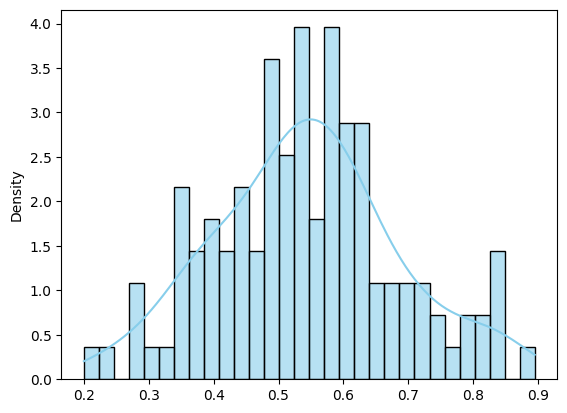

In [29]:
sns.histplot(avg_scores_list, bins=30, kde=True, stat="density", color="skyblue", alpha=0.6)
plt.show()

---

### <= 0.2 Question analysis

In [30]:
def low_answer_rate_questions(data, sex, age, low_score_questions_set):

    sample = sample_prep(data, sex, age)
    if sex not in {"M", "W"}:
        raise ValueError("sex not applicable, input one of 'M' or 'W'")
    if age not in {25, 59, 60}:
        raise ValueError("age not applicable, input one of 25, 59, 60")

    col_prefix = f"{sex}{age}-"
    focal_columns = [x for x in sample.columns if x.startswith(col_prefix)]
    
    for col in focal_columns:
        if sample[col].sum() / sample[col].count() <= 0.2:
            low_score_questions_set.add(col)

In [31]:
low_scoring_questions = set()
for sex in ["M", "W"]:
    for age in [25, 59, 60]:
        sex2 = "Male" if sex == "M" else "Female"
        if age == 25:
            age2 = "18-25"
        elif age == 59:
            age2 = "26-59"
        else:
            age2 = "60+"

        low_answer_rate_questions(data, sex, age, low_scoring_questions)

In [32]:
low_scoring_questions

{'M25-12'}

In [33]:
for col in low_scoring_questions:
    print(f"\n{data[col].rename(f'{col}: {scenarios_questions_dict[col]}').value_counts().rename({scenarios_answers_dict[col]: f'Correct: {scenarios_answers_dict[col]}'})}")


M25-12: Manav, 23, suddenly notices suspicious UPI withdrawals from his bank account soon after using public Wi-Fi. New transactions keep appearing.\nWhat is the best response Manav should do?
0.0    24
1.0     6
Name: count, dtype: int64


---

### >= 0.7 Question analysis

In [34]:
def high_answer_rate_questions(data, sex, age, high_score_questions_set):

    sample = sample_prep(data, sex, age)
    if sex not in {"M", "W"}:
        raise ValueError("sex not applicable, input one of 'M' or 'W'")
    if age not in {25, 59, 60}:
        raise ValueError("age not applicable, input one of 25, 59, 60")

    col_prefix = f"{sex}{age}-"
    focal_columns = [x for x in sample.columns if x.startswith(col_prefix)]
    
    for col in focal_columns:
        if sample[col].sum() / sample[col].count() >= 0.7:
            high_score_questions_set.add(col)

In [35]:
high_scoring_questions = set()
for sex in ["M", "W"]:
    for age in [25, 59, 60]:
        sex2 = "Male" if sex == "M" else "Female"
        if age == 25:
            age2 = "18-25"
        elif age == 59:
            age2 = "26-59"
        else:
            age2 = "60+"

        high_answer_rate_questions(data, sex, age, high_scoring_questions)

In [36]:
print("Total No. of questions affected:", len(high_scoring_questions))

Total No. of questions affected: 15


In [ ]:
for col in high_scoring_questions:
    print(f"\n{data[col].rename(f'{col}: {scenarios_questions_dict[col]}').value_counts().rename({scenarios_answers_dict[col]: f'Correct: {scenarios_answers_dict[col]}'})}")

---

### >= 0.8 Question analysis

In [ ]:
def high_answer_rate_questions(data, sex, age, high_score_questions_set):

    sample = sample_prep(data, sex, age)
    if sex not in {"M", "W"}:
        raise ValueError("sex not applicable, input one of 'M' or 'W'")
    if age not in {25, 59, 60}:
        raise ValueError("age not applicable, input one of 25, 59, 60")

    col_prefix = f"{sex}{age}-"
    focal_columns = [x for x in sample.columns if x.startswith(col_prefix)]
    
    for col in focal_columns:
        if sample[col].sum() / sample[col].count() >= 0.8:
            high_score_questions_set.add(col)

In [ ]:
high_scoring_questions = set()
for sex in ["M", "W"]:
    for age in [25, 59, 60]:
        sex2 = "Male" if sex == "M" else "Female"
        if age == 25:
            age2 = "18-25"
        elif age == 59:
            age2 = "26-59"
        else:
            age2 = "60+"

        high_answer_rate_questions(data, sex, age, high_scoring_questions)

In [ ]:
print("Total No. of questions affected:", len(high_scoring_questions))

In [ ]:
for col in high_scoring_questions:
    print(f"\n{data[col].rename(f'{col}: {scenarios_questions_dict[col]}').value_counts().rename({scenarios_answers_dict[col]: f'Correct: {scenarios_answers_dict[col]}'})}")

---

### Crisis Management scoring

In [ ]:
data = data.copy()

for sex, text in [("M", "Male") , ("W", "Female")]:
    for age_crisis, age_text in zip([1, 2, 3], ["25", "59", "60"]):
        mask = ((data["gender_text"] == text) & (data["age_crisis"] == age_crisis))
        col = [f"{sex}{age_text}-{x}" for x in range(1, 21)]
        
        data.loc[mask, "crisis_score"] = data.loc[mask, col].fillna(0).sum(axis = 1)

data = data.copy()

data["risklit_quartile"] = pd.qcut(data["TotalScore_%"],q = 4, labels = False, duplicates = "raise" ) + 1

In [ ]:
main = data.copy()

In [ ]:
# wealth_quartile = pd.qcut(main.loc[~ (main["wealth"]==-1)]["wealth"],q = 4, labels = False, duplicates = "raise" ) + 1
# main["wealth_quartile"] = wealth_quartile

# main["risklit_quartile_income"] = pd.qcut(main.loc[~ (main["income"]==-1)]["TotalScore_%"],q = 4, labels = False, duplicates = "raise" ) + 1
# main["risklit_quartile_wealth"] = pd.qcut(main.loc[~ (main["wealth"]==-1)]["TotalScore_%"],q = 4, labels = False, duplicates = "raise" ) + 1

In [ ]:
#Global Vras:
ques_cols = ["certainty1", "certainty2", "certainty3", "certainty4", "certainty5",
             "graph1", "graph2", "graph3",
             "numeracy1", "numeracy2", "numeracy3"]

facet_cols = ["Certainty_5", "GraphLiteracy_3", "Numeracy_3"]

facet_percent_cols = ["Certainty_%","GraphLiteracy_%", "Numeracy_%"]

In [ ]:
main.describe()

# Study 3 START - India Dynata 2

### Correlation Matrix - individual question

In [ ]:
output_rows = []
output_index = []

for sex, text in [("M", "Male") , ("W", "Female")]:
    for age_crisis, age_text in zip([1, 2, 3], ["25", "59", "60"]):
        mask = ((main["gender_text"] == text) & (main["age_crisis"] == age_crisis))

        working_data = main.loc[mask].copy()
        demograph = f"{sex}{age_text}"
        col = ques_cols + ["crisis_score"]
        
        output_subrow = []
        for c in col:
            corr, pval = stats.pearsonr(working_data[c], working_data["crisis_score"])
            stars = 0
            if pval <= 0.01:
                stars = 3
            elif pval <= 0.05:
                stars = 2
            elif pval <= 0.1:
                stars = 1
            corr_text = f"{corr:.3f}{'*' * stars}"

            output_subrow.append(corr_text)
        
        output_rows.append(output_subrow)
        output_index.append(demograph)

output_dataframe = pd.DataFrame(data = output_rows, columns = col, index = output_index)

        

In [ ]:
output_dataframe

IMPORTANT: nan values denote that this variable has constant values OR either all of them are 1 or all of them are 0. Here certainty3 among M25 crowd is constant

*** --> CI < 0.01

** --> CI < 0.05

\* --> CI < 0.1


In [ ]:
main.loc[(main["gender_text"] == "Male") & (main["age_crisis"] == 1), "certainty3"].value_counts()

---

### Correlation Matrix - facets and total

In [ ]:
output_rows = []
output_index = []

for sex, text in [("M", "Male") , ("W", "Female")]:
    for age_crisis, age_text in zip([1, 2, 3], ["25", "59", "60"]):
        mask = ((main["gender_text"] == text) & (main["age_crisis"] == age_crisis))
        working_data = main.loc[mask].copy()
        
        demograph = f"{sex}{age_text}"
        col = facet_cols + ["TotalScore_11", "crisis_score"]
        output_subrow = []
        for c in col:
            corr, pval = stats.pearsonr(working_data[c], working_data["crisis_score"])
            stars = 0
            if pval <= 0.01:
                stars = 3
            elif pval <= 0.05:
                stars = 2
            elif pval <= 0.1:
                stars = 1
            corr_text = f"{corr:.3f}{'*' * stars}"

            output_subrow.append(corr_text)
        
        output_rows.append(output_subrow)
        output_index.append(demograph)

output_dataframe = pd.DataFrame(data = output_rows, columns = col, index = output_index)

        

In [ ]:
output_dataframe

---

### Correlation Matrix - Combined

In [ ]:
col = ques_cols + facet_cols + ["TotalScore_11", "crisis_score"]

output_subrow = []
for c in col:
    corr, pval = stats.pearsonr(working_data[c], working_data["crisis_score"])
    stars = 0
    if pval <= 0.01:
        stars = 3
    elif pval <= 0.05:
        stars = 2
    elif pval <= 0.1:
        stars = 1
    corr_text = f"{corr:.3f}{'*' * stars}"
    output_subrow.append(corr_text)

output_dataframe = pd.DataFrame(data = [output_subrow], columns = col, index = ["combined"])

In [ ]:
output_dataframe

---

---

In [ ]:
main.to_csv("160925_IndiaDynata2.csv")
aa

## WITH CONSTANT

## Linear Regression: Crisis Score by Risk literacy

### V1: Without any control variables

In [ ]:
import statsmodels.api as sm

data = main.copy()

model = sm.OLS(data["crisis_score"], sm.add_constant(data["risklit_quartile"]))

res = model.fit()
print(res.summary())

### V2: With control of education

In [ ]:
import statsmodels.api as sm

data = main.copy()


model = sm.OLS(data["crisis_score"], sm.add_constant(data[["risklit_quartile", "isced"]]))

res = model.fit()
print(res.summary())

### V3: With control of education and age

In [ ]:
import statsmodels.api as sm

data = main.copy()

model = sm.OLS(data["crisis_score"], sm.add_constant(data[["risklit_quartile", "isced", "age_rec"]]))

# Age group 2 = 18 to 35 y/o
# Age group 3 = 36 to 55 y/o
# Age group 4 = 56 to 75 y/o 

res = model.fit()
print(res.summary())

---

## Linear Regression: Crisis Score by Risk literacy FOR 36-55 years old

### V1: without control of education

In [ ]:
data = main.loc[main["age_rec"] == 3].copy()

model = sm.OLS(data["crisis_score"], sm.add_constant(data["risklit_quartile"]))

res = model.fit()
print(res.summary())

### V2: with control of education

In [ ]:
data = main.loc[main["age_rec"] == 3].copy()

model = sm.OLS(data["crisis_score"], sm.add_constant(data[["risklit_quartile", "isced"]]))

res = model.fit()
print(res.summary())

---

# PLEASE READ: AS OF 09/09/25 2PM, ALL ANALYSIS ENDS HERE

### Following are place holders for further analysis, if at all, instead of recoding again

---

---

---

---

---

In [ ]:
main.to_csv("India_dynata2_pilot_090925.csv")
aa

## Linear Regression: Financial Planning 2 by Risk literacy

In [ ]:
finplan2_data = main.copy()
risklit_quartile = pd.qcut(finplan2_data["TotalScore_19"],q = 4, labels = False ) + 1
finplan2_data["risklit_quartile"] = risklit_quartile.copy()

### V1: Without any control variables

In [ ]:
import statsmodels.api as sm

data = finplan2_data.copy()

model = sm.OLS(data["FinancialPlanning1_%"], sm.add_constant(data["risklit_quartile"]))

res = model.fit()
print(res.summary())

### V2: With control of education

In [ ]:
import statsmodels.api as sm

data = finplan2_data.copy()


model = sm.OLS(data["FinancialPlanning1_%"], sm.add_constant(data[["risklit_quartile", "isced"]]))

res = model.fit()
print(res.summary())

### V3: With control of education and age

In [ ]:
import statsmodels.api as sm

data = finplan2_data.copy()

model = sm.OLS(data["FinancialPlanning1_%"], sm.add_constant(data[["risklit_quartile", "isced", "age_rec"]]))

# Age group 2 = 18 to 35 y/o
# Age group 3 = 36 to 55 y/o
# Age group 4 = 56 to 75 y/o 

res = model.fit()
print(res.summary())

### V4: With control of education, age and Financial Lit

In [ ]:
import statsmodels.api as sm

data = finplan2_data.copy()

model = sm.OLS(data["FinancialPlanning1_%"], sm.add_constant(data[["risklit_quartile", "isced", "age_rec", "FinancialLiteracy_%"]]))

# Age group 2 = 18 to 35 y/o
# Age group 3 = 36 to 55 y/o
# Age group 4 = 56 to 75 y/o 

res = model.fit()
print(res.summary())

### V5: With control of education, age, Financial Lit, CRT

In [ ]:
import statsmodels.api as sm

data = finplan2_data.copy()

model = sm.OLS(data["FinancialPlanning1_%"], sm.add_constant(data[["risklit_quartile", "isced", "age_rec", "FinancialLiteracy_%", "CRTScore_%"]]))

# Age group 2 = 18 to 35 y/o
# Age group 3 = 36 to 55 y/o
# Age group 4 = 56 to 75 y/o 

res = model.fit()
print(res.summary())

---

## Linear Regression: Financial Planning 2 by Risk literacy FOR 36-55 years old

### V1: without control of education

In [ ]:
data = finplan2_data.loc[finplan2_data["age_rec"] == 3].copy()

model = sm.OLS(data["FinancialPlanning1_%"], sm.add_constant(data["risklit_quartile"]))

res = model.fit()
print(res.summary())

### V2: with control of education

In [ ]:
data = finplan2_data.loc[finplan2_data["age_rec"] == 3].copy()

model = sm.OLS(data["FinancialPlanning1_%"], sm.add_constant(data[["risklit_quartile", "isced"]]))

res = model.fit()
print(res.summary())

### V3: with control of education and financial literacy

In [ ]:
data = finplan2_data.loc[finplan2_data["age_rec"] == 3].copy()

model = sm.OLS(data["FinancialPlanning1_%"], sm.add_constant(data[["risklit_quartile", "isced", "FinancialLiteracy_%"]]))

res = model.fit()
print(res.summary())

### V4: with control of education, financial literacy, CRT

In [ ]:
data = finplan2_data.loc[finplan2_data["age_rec"] == 3].copy()

model = sm.OLS(data["FinancialPlanning1_%"], sm.add_constant(data[["risklit_quartile", "isced", "FinancialLiteracy_%", "CRTScore_%"]]))

res = model.fit()
print(res.summary())

---

---

## WITHOUT CONSTANT

## Linear Regression: Financial Planning 1 by Risk literacy

In [ ]:
finplan1_data = wealth_filtered.copy()
risklit_quartile = pd.qcut(finplan1_data["TotalScore_19"],q = 4, labels = False ) + 1
finplan1_data["risklit_quartile"] = risklit_quartile.copy()




In [ ]:
cols = ["savings_bank", "gov_bonds", "mutual_funds", "stocks"]
[col + "_dummy" for col in cols]


In [ ]:
finplan1_data

### V1: Without any control variables

In [ ]:
import statsmodels.api as sm

data = finplan1_data.copy()

model = sm.OLS(data["FinancialPlanning1_%"], data["risklit_quartile"])

res = model.fit()
print(res.summary())

### V2: With control of education

In [ ]:
import statsmodels.api as sm

data = finplan1_data.copy()


model = sm.OLS(data["FinancialPlanning1_%"], data[["risklit_quartile", "isced"]])

res = model.fit()
print(res.summary())

### V3: With control of education and age

In [ ]:
import statsmodels.api as sm

data = finplan1_data.copy()

model = sm.OLS(data["FinancialPlanning1_%"], data[["risklit_quartile", "isced", "age_rec"]])

# Age group 2 = 18 to 35 y/o
# Age group 3 = 36 to 55 y/o
# Age group 4 = 56 to 75 y/o 

res = model.fit()
print(res.summary())

### V4: With control of education, age and Financial Lit

In [ ]:
import statsmodels.api as sm

data = finplan1_data.copy()

model = sm.OLS(data["FinancialPlanning1_%"], data[["risklit_quartile", "isced", "age_rec", "FinancialLiteracy_%"]])

# Age group 2 = 18 to 35 y/o
# Age group 3 = 36 to 55 y/o
# Age group 4 = 56 to 75 y/o 

res = model.fit()
print(res.summary())

### V5: With control of education, age, Financial Lit, CRT

In [ ]:
import statsmodels.api as sm

data = finplan1_data.copy()

model = sm.OLS(data["FinancialPlanning1_%"], data[["risklit_quartile", "isced", "age_rec", "FinancialLiteracy_%", "CRTScore_%"]])

# Age group 2 = 18 to 35 y/o
# Age group 3 = 36 to 55 y/o
# Age group 4 = 56 to 75 y/o 

res = model.fit()
print(res.summary())

---

## Linear Regression: Financial Planning 1 by Risk literacy FOR 36-55 years old

### V1: without control of education

In [ ]:
data = finplan1_data.loc[finplan1_data["age_rec"] == 3].copy()

model = sm.OLS(data["FinancialPlanning1_%"], data["risklit_quartile"])

res = model.fit()
print(res.summary())

### V2: with control of education

In [ ]:
data = finplan1_data.loc[finplan1_data["age_rec"] == 3].copy()

model = sm.OLS(data["FinancialPlanning1_%"], data[["risklit_quartile", "isced"]])

res = model.fit()
print(res.summary())

### V3: with control of education and financial literacy

In [ ]:
data = finplan1_data.loc[finplan1_data["age_rec"] == 3].copy()

model = sm.OLS(data["FinancialPlanning1_%"], data[["risklit_quartile", "isced", "FinancialLiteracy_%"]])

res = model.fit()
print(res.summary())

### V4: with control of education, financial literacy, CRT

In [ ]:
data = finplan1_data.loc[finplan1_data["age_rec"] == 3].copy()

model = sm.OLS(data["FinancialPlanning1_%"], data[["risklit_quartile", "isced", "FinancialLiteracy_%", "CRTScore_%"]])

res = model.fit()
print(res.summary())

---

## Linear Regression: Financial Planning 2 by Risk literacy

In [ ]:
finplan2_data = main.copy()
risklit_quartile = pd.qcut(finplan2_data["TotalScore_19"],q = 4, labels = False ) + 1
finplan2_data["risklit_quartile"] = risklit_quartile.copy()

### V1: Without any control variables

In [ ]:
import statsmodels.api as sm

data = finplan2_data.copy()

model = sm.OLS(data["FinancialPlanning1_%"], data["risklit_quartile"])

res = model.fit()
print(res.summary())

### V2: With control of education

In [ ]:
import statsmodels.api as sm

data = finplan2_data.copy()


model = sm.OLS(data["FinancialPlanning1_%"], data[["risklit_quartile", "isced"]])

res = model.fit()
print(res.summary())

### V3: With control of education and age

In [ ]:
import statsmodels.api as sm

data = finplan2_data.copy()

model = sm.OLS(data["FinancialPlanning1_%"], data[["risklit_quartile", "isced", "age_rec"]])

# Age group 2 = 18 to 35 y/o
# Age group 3 = 36 to 55 y/o
# Age group 4 = 56 to 75 y/o 

res = model.fit()
print(res.summary())

### V4: With control of education, age and Financial Lit

In [ ]:
import statsmodels.api as sm

data = finplan2_data.copy()

model = sm.OLS(data["FinancialPlanning1_%"], data[["risklit_quartile", "isced", "age_rec", "FinancialLiteracy_%"]])

# Age group 2 = 18 to 35 y/o
# Age group 3 = 36 to 55 y/o
# Age group 4 = 56 to 75 y/o 

res = model.fit()
print(res.summary())

### V5: With control of education, age, Financial Lit, CRT

In [ ]:
import statsmodels.api as sm

data = finplan2_data.copy()

model = sm.OLS(data["FinancialPlanning1_%"], data[["risklit_quartile", "isced", "age_rec", "FinancialLiteracy_%", "CRTScore_%"]])

# Age group 2 = 18 to 35 y/o
# Age group 3 = 36 to 55 y/o
# Age group 4 = 56 to 75 y/o 

res = model.fit()
print(res.summary())

---

## Linear Regression: Financial Planning 2 by Risk literacy FOR 36-55 years old

### V1: without control of education

In [ ]:
data = finplan2_data.loc[finplan2_data["age_rec"] == 3].copy()

model = sm.OLS(data["FinancialPlanning1_%"], data["risklit_quartile"])

res = model.fit()
print(res.summary())

### V2: with control of education

In [ ]:
data = finplan2_data.loc[finplan2_data["age_rec"] == 3].copy()

model = sm.OLS(data["FinancialPlanning1_%"], data[["risklit_quartile", "isced"]])

res = model.fit()
print(res.summary())

### V3: with control of education and financial literacy

In [ ]:
data = finplan2_data.loc[finplan2_data["age_rec"] == 3].copy()

model = sm.OLS(data["FinancialPlanning1_%"], data[["risklit_quartile", "isced", "FinancialLiteracy_%"]])

res = model.fit()
print(res.summary())

### V4: with control of education, financial literacy, CRT

In [ ]:
data = finplan2_data.loc[finplan2_data["age_rec"] == 3].copy()

model = sm.OLS(data["FinancialPlanning1_%"], data[["risklit_quartile", "isced", "FinancialLiteracy_%", "CRTScore_%"]])

res = model.fit()
print(res.summary())

---

---

## Linear Regression: Risk Alignment Residuals by Risk literacy

In [ ]:
finplan2_data = main.copy()
risklit_quartile = pd.qcut(finplan2_data["TotalScore_19"],q = 4, labels = False ) + 1
finplan2_data["risklit_quartile"] = risklit_quartile.copy()

### V1: Without any control variables

In [ ]:
import statsmodels.api as sm

data = finplan2_data.copy()

model = sm.OLS(data["RiskAlignment_residual"].abs(), sm.add_constant(data["risklit_quartile"]))

res = model.fit()
print(res.summary())

### V2: With control of education

In [ ]:
import statsmodels.api as sm

data = finplan2_data.copy()


model = sm.OLS(data["RiskAlignment_residual"].abs(), sm.add_constant(data[["risklit_quartile", "isced"]]))

res = model.fit()
print(res.summary())

### V3: With control of education and age

In [ ]:
import statsmodels.api as sm

data = finplan2_data.copy()

model = sm.OLS(data["RiskAlignment_residual"].abs(), sm.add_constant(data[["risklit_quartile", "isced", "age_rec"]]))

# Age group 2 = 18 to 35 y/o
# Age group 3 = 36 to 55 y/o
# Age group 4 = 56 to 75 y/o 

res = model.fit()
print(res.summary())

### V4: With control of education, age and Financial Lit

In [ ]:
import statsmodels.api as sm

data = finplan2_data.copy()

model = sm.OLS(data["RiskAlignment_residual"].abs(), sm.add_constant(data[["risklit_quartile", "isced", "age_rec", "FinancialLiteracy_%"]]))

# Age group 2 = 18 to 35 y/o
# Age group 3 = 36 to 55 y/o
# Age group 4 = 56 to 75 y/o 

res = model.fit()
print(res.summary())

### V5: With control of education, age, Financial Lit, CRT

In [ ]:
import statsmodels.api as sm

data = finplan2_data.copy()

model = sm.OLS(data["RiskAlignment_residual"].abs(), sm.add_constant(data[["risklit_quartile", "isced", "age_rec", "FinancialLiteracy_%", "CRTScore_%"]]))

# Age group 2 = 18 to 35 y/o
# Age group 3 = 36 to 55 y/o
# Age group 4 = 56 to 75 y/o 

res = model.fit()
print(res.summary())

---

## Linear Regression: Risk Alignment residuals by Risk literacy FOR 36-55 years old

### V1: without control of education

In [ ]:
data = finplan2_data.loc[finplan2_data["age_rec"] == 3].copy()

model = sm.OLS(data["RiskAlignment_residual"].abs(), sm.add_constant(data["risklit_quartile"]))

res = model.fit()
print(res.summary())

### V2: with control of education

In [ ]:
data = finplan2_data.loc[finplan2_data["age_rec"] == 3].copy()

model = sm.OLS(data["RiskAlignment_residual"].abs(), sm.add_constant(data[["risklit_quartile", "isced"]]))

res = model.fit()
print(res.summary())

### V3: with control of education and financial literacy

In [ ]:
data = finplan2_data.loc[finplan2_data["age_rec"] == 3].copy()

model = sm.OLS(data["RiskAlignment_residual"].abs(), sm.add_constant(data[["risklit_quartile", "isced", "FinancialLiteracy_%"]]))

res = model.fit()
print(res.summary())

### V4: with control of education, financial literacy, CRT

In [ ]:
data = finplan2_data.loc[finplan2_data["age_rec"] == 3].copy()

model = sm.OLS(data["RiskAlignment_residual"].abs(), sm.add_constant(data[["risklit_quartile", "isced", "FinancialLiteracy_%", "CRTScore_%"]]))

res = model.fit()
print(res.summary())

---

---

## Linear Regression: Risk Alignment (Felix) by Risk literacy

In [ ]:
finplan2_data = main.copy()
risklit_quartile = pd.qcut(finplan2_data["TotalScore_19"],q = 4, labels = False ) + 1
finplan2_data["risklit_quartile"] = risklit_quartile.copy()

### V1: Without any control variables

In [ ]:
import statsmodels.api as sm

data = finplan2_data.copy()

model = sm.OLS(data["RiskAlignment_felix"].abs(), sm.add_constant(data["risklit_quartile"]))

res = model.fit()
print(res.summary())

### V2: With control of education

In [ ]:
import statsmodels.api as sm

data = finplan2_data.copy()


model = sm.OLS(data["RiskAlignment_felix"].abs(), sm.add_constant(data[["risklit_quartile", "isced"]]))

res = model.fit()
print(res.summary())

### V3: With control of education and age

In [ ]:
import statsmodels.api as sm

data = finplan2_data.copy()

model = sm.OLS(data["RiskAlignment_felix"].abs(), sm.add_constant(data[["risklit_quartile", "isced", "age_rec"]]))

# Age group 2 = 18 to 35 y/o
# Age group 3 = 36 to 55 y/o
# Age group 4 = 56 to 75 y/o 

res = model.fit()
print(res.summary())

### V4: With control of education, age and Financial Lit

In [ ]:
import statsmodels.api as sm

data = finplan2_data.copy()

model = sm.OLS(data["RiskAlignment_felix"].abs(), sm.add_constant(data[["risklit_quartile", "isced", "age_rec", "FinancialLiteracy_%"]]))

# Age group 2 = 18 to 35 y/o
# Age group 3 = 36 to 55 y/o
# Age group 4 = 56 to 75 y/o 

res = model.fit()
print(res.summary())

### V5: With control of education, age, Financial Lit, CRT

In [ ]:
import statsmodels.api as sm

data = finplan2_data.copy()

model = sm.OLS(data["RiskAlignment_felix"].abs(), sm.add_constant(data[["risklit_quartile", "isced", "age_rec", "FinancialLiteracy_%", "CRTScore_%"]]))

# Age group 2 = 18 to 35 y/o
# Age group 3 = 36 to 55 y/o
# Age group 4 = 56 to 75 y/o 

res = model.fit()
print(res.summary())

---

## Linear Regression: Risk Alignement (Felix) by Risk literacy FOR 36-55 years old

### V1: without control of education

In [ ]:
data = finplan2_data.loc[finplan2_data["age_rec"] == 3].copy()

model = sm.OLS(data["RiskAlignment_felix"].abs(), sm.add_constant(data["risklit_quartile"]))

res = model.fit()
print(res.summary())

### V2: with control of education

In [ ]:
data = finplan2_data.loc[finplan2_data["age_rec"] == 3].copy()

model = sm.OLS(data["RiskAlignment_felix"].abs(), sm.add_constant(data[["risklit_quartile", "isced"]]))

res = model.fit()
print(res.summary())

### V3: with control of education and financial literacy

In [ ]:
data = finplan2_data.loc[finplan2_data["age_rec"] == 3].copy()

model = sm.OLS(data["RiskAlignment_felix"].abs(), sm.add_constant(data[["risklit_quartile", "isced", "FinancialLiteracy_%"]]))

res = model.fit()
print(res.summary())

### V4: with control of education, financial literacy, CRT

In [ ]:
data = finplan2_data.loc[finplan2_data["age_rec"] == 3].copy()

model = sm.OLS(data["RiskAlignment_felix"].abs(), sm.add_constant(data[["risklit_quartile", "isced", "FinancialLiteracy_%", "CRTScore_%"]]))

res = model.fit()
print(res.summary())

---

---

## Ordinal Logistic Regression: Emergency funds dummy by Risk literacy

### V1: with control of education, age, financial literacy

In [ ]:
import statsmodels.api as sm
from statsmodels.miscmodels.ordinal_model import OrderedModel

data = finplan2_data.copy()

data["financialplanning_emergency"] = pd.Categorical(data["financialplanning_emergency"], ordered=True)

model = OrderedModel(data["financialplanning_emergency"], data[["risklit_quartile", "isced", "age_rec", "FinancialLiteracy_%"]],
                     distr='logit')

# Age group 2 = 18 to 35 y/o
# Age group 3 = 36 to 55 y/o
# Age group 4 = 56 to 75 y/o 

res = model.fit(method='bfgs')
print(res.summary())

### V2: with control of education, age, financial literacy, CRT

In [ ]:
import statsmodels.api as sm
from statsmodels.miscmodels.ordinal_model import OrderedModel

data = finplan2_data.copy()

data["financialplanning_emergency"] = pd.Categorical(data["financialplanning_emergency"], ordered=True)

model = OrderedModel(data["financialplanning_emergency"], data[["risklit_quartile", "isced", "age_rec", "FinancialLiteracy_%", "CRTScore_%"]],
                     distr='logit')

# Age group 2 = 18 to 35 y/o
# Age group 3 = 36 to 55 y/o
# Age group 4 = 56 to 75 y/o 

res = model.fit(method='bfgs')
print(res.summary())

---

---

## Ordinal Logistic Regression: Retirement funds dummy by Risk literacy

### V1: with control of education, age, financial literacy

In [ ]:
import statsmodels.api as sm
from statsmodels.miscmodels.ordinal_model import OrderedModel

data = finplan2_data.copy()

data["financialplanning_retirement"] = pd.Categorical(data["financialplanning_retirement"], ordered=True)

model = OrderedModel(data["financialplanning_retirement"], data[["risklit_quartile", "isced", "age_rec", "FinancialLiteracy_%"]],
                     distr='logit')

# Age group 2 = 18 to 35 y/o
# Age group 3 = 36 to 55 y/o
# Age group 4 = 56 to 75 y/o 

res = model.fit(method='bfgs')
print(res.summary())

### V2: with control of education, age, financial literacy, CRT

In [ ]:
import statsmodels.api as sm
from statsmodels.miscmodels.ordinal_model import OrderedModel

data = finplan2_data.copy()

data["financialplanning_retirement"] = pd.Categorical(data["financialplanning_retirement"], ordered=True)

model = OrderedModel(data["financialplanning_retirement"], data[["risklit_quartile", "isced", "age_rec", "FinancialLiteracy_%", "CRTScore_%"]],
                     distr='logit')

# Age group 2 = 18 to 35 y/o
# Age group 3 = 36 to 55 y/o
# Age group 4 = 56 to 75 y/o 

res = model.fit(method='bfgs')
print(res.summary())

---

---


## Linear Regression: Investment Behaviour by Risk literacy

### V1: With control of education, age and Financial Lit

In [ ]:
import statsmodels.api as sm

data = finplan2_data.copy()

model = sm.OLS(data["investment_behaviour"].abs(), sm.add_constant(data[["risklit_quartile", "isced", "age_rec", "FinancialLiteracy_%"]]))

# Age group 2 = 18 to 35 y/o
# Age group 3 = 36 to 55 y/o
# Age group 4 = 56 to 75 y/o 

res = model.fit()
print(res.summary())

### V2: With control of education, age, Financial Lit, CRT

In [ ]:
import statsmodels.api as sm

data = finplan2_data.copy()

model = sm.OLS(data["investment_behaviour"].abs(), sm.add_constant(data[["risklit_quartile", "isced", "age_rec", "FinancialLiteracy_%", "CRTScore_%"]]))

# Age group 2 = 18 to 35 y/o
# Age group 3 = 36 to 55 y/o
# Age group 4 = 56 to 75 y/o 

res = model.fit()
print(res.summary())

---

---

## Linear Regression: Investments by Risk literacy

### V1: With control of education, age and Financial Lit

In [ ]:
import statsmodels.api as sm

data = finplan2_data.copy()

model = sm.OLS(data["investments"].abs(), sm.add_constant(data[["risklit_quartile", "isced", "age_rec", "FinancialLiteracy_%"]]))

# Age group 2 = 18 to 35 y/o
# Age group 3 = 36 to 55 y/o
# Age group 4 = 56 to 75 y/o 

res = model.fit()
print(res.summary())

### V2: With control of education, age, Financial Lit, CRT

In [ ]:
import statsmodels.api as sm

data = finplan2_data.copy()

model = sm.OLS(data["investments"].abs(), sm.add_constant(data[["risklit_quartile", "isced", "age_rec", "FinancialLiteracy_%", "CRTScore_%"]]))

# Age group 2 = 18 to 35 y/o
# Age group 3 = 36 to 55 y/o
# Age group 4 = 56 to 75 y/o 

res = model.fit()
print(res.summary())

---

---

## Linear Regression: Riskier Investments by Risk literacy

### V1: With control of education, age and Financial Lit

In [ ]:
import statsmodels.api as sm

data = finplan2_data.copy()

model = sm.OLS(data["risky_investments"].abs(), sm.add_constant(data[["risklit_quartile", "isced", "age_rec", "FinancialLiteracy_%"]]))

# Age group 2 = 18 to 35 y/o
# Age group 3 = 36 to 55 y/o
# Age group 4 = 56 to 75 y/o 

res = model.fit()
print(res.summary())

### V2: With control of education, age, Financial Lit, CRT

In [ ]:
import statsmodels.api as sm

data = finplan2_data.copy()

model = sm.OLS(data["risky_investments"], sm.add_constant(data[["risklit_quartile", "isced", "age_rec", "FinancialLiteracy_%", "CRTScore_%"]]))

# Age group 2 = 18 to 35 y/o
# Age group 3 = 36 to 55 y/o
# Age group 4 = 56 to 75 y/o 

res = model.fit()
print(res.summary())

---

---

## Willingness to take risk vs risk literacy

In [ ]:
fig, axis = plt.subplots(1, 1, figsize = [6, 6])

sns.regplot( x = main["TotalScore_%"], y = (main["RiskAppetite1_%"] + main["RiskAppetite2_%"])/2, scatter_kws={"color": "blue"}, line_kws={"color": "red"})
axis.set(ylabel='Risk Appetite', xlabel='Total Score_%')

axis.set_xticks(np.arange(0, 110, step = 10))
axis.set_yticks(np.arange(0, 110, step = 10))
plt.show()

## Financial Planning 1 vs risk literacy

In [ ]:
fig, axis = plt.subplots(1, 1, figsize = [6, 6])

sns.regplot( x = main["TotalScore_%"], y = main["FinancialPlanning1_%"], scatter_kws={"color": "blue"}, line_kws={"color": "red"})
axis.set(ylabel='Financial Planning 1', xlabel='Total Score_%')

axis.set_xticks(np.arange(0, 110, step = 10))
axis.set_yticks(np.arange(0, 110, step = 10))
plt.show()

## Financial Planning 2 vs risk literacy

In [ ]:
fig, axis = plt.subplots(1, 1, figsize = [6, 6])

sns.regplot( x = main["TotalScore_%"], y = main["FinancialPlanning2_%"], scatter_kws={"color": "blue"}, line_kws={"color": "red"})
axis.set(ylabel='Financial Planning 2', xlabel='Total Score_%')

axis.set_xticks(np.arange(0, 110, step = 10))
axis.set_yticks(np.arange(0, 110, step = 10))
plt.show()

## Risky Assets ownership vs risk literacy

In [ ]:
fig, axis = plt.subplots(1, 1, figsize = [6, 6])

sns.regplot( x = main["TotalScore_%"], y = main["RiskAssets_%"], scatter_kws={"color": "blue"}, line_kws={"color": "red"})
axis.set(ylabel='Risky assets ownership', xlabel='Total Score_%')

axis.set_xticks(np.arange(0, 110, step = 10))
axis.set_yticks(np.arange(0, 110, step = 10))
plt.show()

## Safe Assets ownership vs risk literacy

In [ ]:
fig, axis = plt.subplots(1, 1, figsize = [6, 6])

sns.regplot( x = main["TotalScore_%"], y = main["SafeAssets_%"], scatter_kws={"color": "blue"}, line_kws={"color": "red"})
axis.set(ylabel='Safe assets ownership', xlabel='Total Score_%')

axis.set_xticks(np.arange(0, 110, step = 10))
axis.set_yticks(np.arange(0, 110, step = 10))
plt.show()

## Financial Literacy vs risk literacy

In [ ]:
fig, axis = plt.subplots(1, 1, figsize = [6, 6])

sns.regplot( x = main["TotalScore_%"], y = main["FinancialLiteracy_%"], scatter_kws={"color": "blue"}, line_kws={"color": "red"})
axis.set(ylabel='Financial Literacy', xlabel='Total Score_%')

axis.set_xticks(np.arange(0, 110, step = 10))
axis.set_yticks(np.arange(0, 110, step = 10))
plt.show()

## CRT vs risk literacy

In [ ]:
fig, axis = plt.subplots(1, 1, figsize = [6, 6])

sns.regplot( x = main["TotalScore_%"], y = main["CRTScore_%"], scatter_kws={"color": "blue"}, line_kws={"color": "red"})
axis.set(ylabel='CRT score', xlabel='Total Score_%')

axis.set_xticks(np.arange(0, 110, step = 10))
axis.set_yticks(np.arange(0, 110, step = 10))
plt.show()

## Risk Alignment residuals vs Risk Literacy

In [ ]:
fig, axis = plt.subplots(1, 1, figsize = [6, 6])

sns.regplot( x = main["TotalScore_%"], y = main["RiskAlignment_residual"].abs(), scatter_kws={"color": "blue"}, line_kws={"color": "red"})
axis.set(ylabel='RiskAlignment_residual', xlabel='Total Score_%')

axis.set_xticks(np.arange(0, 110, step = 10))
axis.set_yticks(np.arange(0, 110, step = 10))
plt.show()

In [ ]:
print("Correlation coefficient between Risk Lit and", 
      "absolute value of risk alignement residuals: \n", 
      main["TotalScore_%"].corr(main["RiskAlignment_residual"].abs(), method = "pearson"))

## Risk Alignment (Felix) vs Risk Literacy

In [ ]:
fig, axis = plt.subplots(1, 1, figsize = [6, 6])

sns.regplot( x = main["TotalScore_%"], y = main["RiskAlignment_felix"].abs(), scatter_kws={"color": "blue"}, line_kws={"color": "red"})
axis.set(ylabel='RiskAlignment_felix', xlabel='Total Score_%')

axis.set_xticks(np.arange(0, 110, step = 10))
axis.set_yticks(np.arange(0, 8, step = 1))
plt.show()

In [ ]:
print("Correlation coefficient between Risk Lit and", 
      "absolute value of risk alignement residuals: \n", 
      main["TotalScore_%"].corr(main["RiskAlignment_felix"].abs(), method = "pearson"))

## Table Output

In [ ]:

def regression_output(data: pd.DataFrame, regression_type: str, dependent_variable: str, independent_variable: str,
                      control_variables: list, depvar_absval: bool = False) -> pd.DataFrame :
    
    if depvar_absval == True:
        data[dependent_variable] = data[dependent_variable].abs().copy()

    if regression_type == "OLS":

        model = sm.OLS(data[dependent_variable],
                       sm.add_constant(data[[independent_variable] + control_variables]))
        res = model.fit()
    
    elif regression_type == "OrderedModel":

        data[dependent_variable] = pd.Categorical(data[dependent_variable], ordered=True)

        model = OrderedModel(data[dependent_variable],
                             data[[independent_variable] + control_variables], distr='logit')
        res = model.fit(method='bfgs')

    else:
        raise ValueError("Unsupported regression_type. Use 'OLS' or 'OrderedModel'.")
    
    def format_coefficient(coef, pval):
        if pval < 0.01:
            stars = "***"
        elif pval < 0.05:
            stars = "**"
        elif pval < 0.10:
            stars = "*"
        else:
            stars = ""
        return f"{coef:.3f}{stars}"
    
    def format_p_value(pval):
        return f'="({pval:.3f})"'
    
    # output = pd.DatFrame(index = ["risklit_quartile", "isced", "age_rec", "FinancialLiteracy_%", "CRTScore_%"])

    rows = []
    for var, coeff, pval in zip(res.params.index, res.params, res.pvalues):
        rows.append([var, str(format_coefficient(coeff, pval))])
        rows.append(["", str(format_p_value(pval))])
    
    output = pd.DataFrame(data = rows, columns = [regression_type, dependent_variable])
    return output


In [ ]:
data = finplan2_data.copy()
import csv
pd.concat([ regression_output(data = data, regression_type = "OLS", dependent_variable = "risky_investments",
                              independent_variable = "risklit_quartile", control_variables = ["isced", "age_rec", "FinancialLiteracy_%", "CRTScore_%"],
                              depvar_absval = False),
            regression_output(data = data, regression_type = "OLS", dependent_variable = "risky_investments",
                              independent_variable = "risklit_quartile", control_variables = ["isced", "age_rec", "FinancialLiteracy_%"],
                              depvar_absval = False)],
                              axis = 1).replace({pd.NA:""})

